In [193]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np


alpha = 0.05
n = 4000
regressor_name = "nn"
coordinate = 0
batch_list = [5, 10, 20]
smallest_batch = min(batch_list)
seed = 1
single_seed = False
strategy = "coin betting"



results_dir = Path("../results/csv/safety_simulations")


In [194]:
# filename = f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
# file = results_dir / filename
# with open(file, "rb") as f:
#     all_martingales = pickle.load(f)

In [195]:
file = f"/home/michele/Documents/testing_conditional_independence/shaer_replication/ecrt/results/csv/safety_simulations/simulations_safety_modelnn_1_seed_n_{n}_martingales.pkl"
with open(file, "rb") as f:
    all_martingales = pickle.load(f)

In [196]:
all_martingales[0]['coin betting']#[2][0] 

{5: {0: array([1.        , 1.        , 1.        , ..., 1.20009506, 1.20009506,
         1.20009506], shape=(4000,))},
 10: {0: array([1.        , 1.        , 1.        , ..., 0.72408755, 0.72408755,
         0.72408755], shape=(4000,))},
 20: {0: array([1.        , 1.        , 1.        , ..., 0.90347484, 0.90347484,
         0.90347484], shape=(4000,))}}

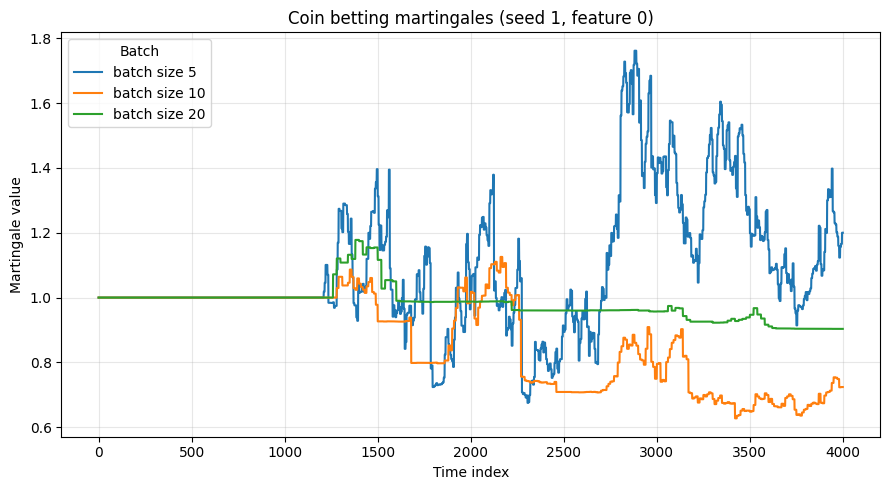

In [197]:
martingales_by_batch = all_martingales[0]["coin betting"]
fig, ax = plt.subplots(figsize=(9, 5))
for batch in sorted(martingales_by_batch):
    values = np.asarray(martingales_by_batch[batch][coordinate])
    ax.plot(np.arange(values.size), values, label=f"batch size {batch}")

ax.set(title=f"Coin betting martingales (seed {seed}, feature {coordinate})",
       xlabel="Time index", ylabel="Martingale value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [198]:
#np.array(
lambdas = {}
for b in batch_list:
    lambdas[b] = [d["lambda"]/5.0 for d in all_martingales[1][0][b]['coin betting']]


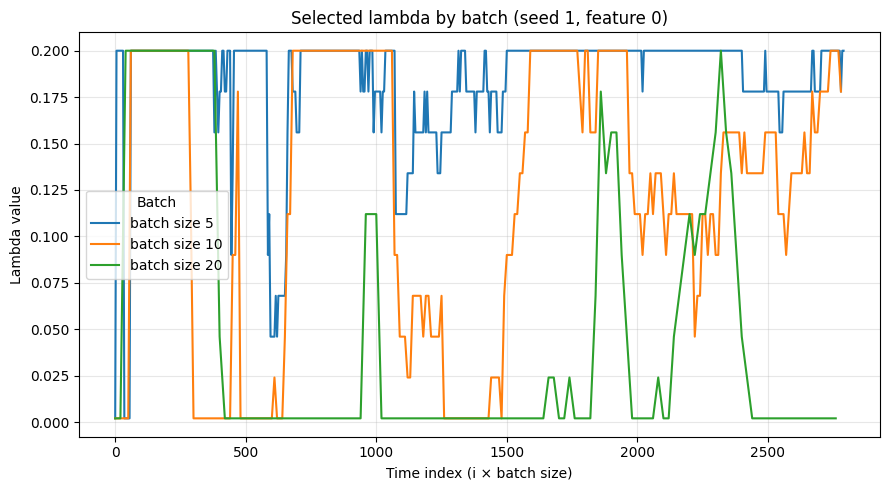

In [199]:
fig, ax = plt.subplots(figsize=(9, 5))
for batch in batch_list:
    values = np.asarray(lambdas[batch])
    ax.plot(np.arange(values.size) * batch, values, label=f"batch size {batch}")

ax.set(title=f"Selected lambda by batch (seed {seed}, feature {coordinate})",
       xlabel="Time index (i × batch size)", ylabel="Lambda value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [200]:
def load_martingales():
    files = []
    if single_seed:
        file = results_dir / f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
        files.append(file)
        if not file.exists():
            raise FileNotFoundError(f"No martingale file found  in {results_dir}")
    else:
        files = sorted(
            results_dir.glob(
                f"simulations_safety_model{regressor_name}_*_seed_martingales.pkl"
            )
        )
        if not files:
            raise FileNotFoundError(f"No martingale files found  in {results_dir}")

    all_martingales = []
    for file in files:
        with open(file, "rb") as f:
            all_martingales.append(pickle.load(f))


    mean_martingales = {}
    for batch in all_martingales[0][strategy]:
        mean_martingales[batch] = {}
        for j in all_martingales[0][strategy][batch]:
            arrays = [m[strategy][batch][j] for m in all_martingales]
            mean_martingales[strategy][batch][j] = np.mean(arrays, axis=0)

    print(f"loaded {len(all_martingales)} seeds")
    return mean_martingales




In [201]:
all_martingales[2]

[np.float64(0.03369345830884629),
 np.float64(0.06435258372087249),
 np.float64(0.0632306132776228),
 np.float64(0.04792985565334979),
 np.float64(0.03629691274176788),
 np.float64(0.08278667568912694),
 np.float64(0.04111659545779813),
 np.float64(0.11037930285561437),
 np.float64(0.08625621841065535),
 np.float64(0.08824652125708841),
 np.float64(0.043400245666918316),
 np.float64(0.04802421031933421),
 np.float64(0.03748406591254513),
 np.float64(0.038608743773093035),
 np.float64(0.05310484356581345),
 np.float64(0.06955322308129072),
 np.float64(0.05131970122995477),
 np.float64(0.10062801270181113),
 np.float64(0.03742270060503552),
 np.float64(0.06650386741070838),
 np.float64(0.07444546680964935),
 np.float64(0.07281186193193727),
 np.float64(0.03727221505370656),
 np.float64(0.06764781944882335),
 np.float64(0.05012830551761002),
 np.float64(0.05023137246005503),
 np.float64(0.09335792766400412),
 np.float64(0.039515572394213855),
 np.float64(0.0350867026751063),
 np.float64(0

In [202]:
print(len(all_martingales[2]))
print(len(lambdas[5]))
print(len(lambdas[10]))


559
559
279


In [203]:
all_martingales[2]

[np.float64(0.03369345830884629),
 np.float64(0.06435258372087249),
 np.float64(0.0632306132776228),
 np.float64(0.04792985565334979),
 np.float64(0.03629691274176788),
 np.float64(0.08278667568912694),
 np.float64(0.04111659545779813),
 np.float64(0.11037930285561437),
 np.float64(0.08625621841065535),
 np.float64(0.08824652125708841),
 np.float64(0.043400245666918316),
 np.float64(0.04802421031933421),
 np.float64(0.03748406591254513),
 np.float64(0.038608743773093035),
 np.float64(0.05310484356581345),
 np.float64(0.06955322308129072),
 np.float64(0.05131970122995477),
 np.float64(0.10062801270181113),
 np.float64(0.03742270060503552),
 np.float64(0.06650386741070838),
 np.float64(0.07444546680964935),
 np.float64(0.07281186193193727),
 np.float64(0.03727221505370656),
 np.float64(0.06764781944882335),
 np.float64(0.05012830551761002),
 np.float64(0.05023137246005503),
 np.float64(0.09335792766400412),
 np.float64(0.039515572394213855),
 np.float64(0.0350867026751063),
 np.float64(0

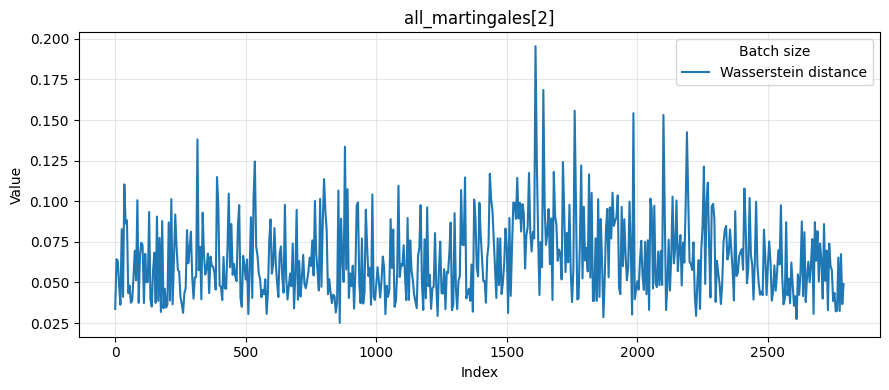

In [204]:
plt.figure(figsize=(9, 4))

seq = all_martingales[2]

plt.plot(np.arange(len(seq)) * smallest_batch, seq, label=f"Wasserstein distance")

plt.legend(title="Batch size")
plt.title("all_martingales[2]")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [205]:
print(len(lambdas[5]))
print(len(all_martingales[2]))

559
559


In [206]:
all_martingales[3]

[2.1098354481985164,
 1.9034768182080848,
 1.6417558209145469,
 2.2855598283578398,
 2.073287488849682,
 2.2533064056645467,
 2.5917298820557684,
 2.64432654970618,
 2.1524164094965137,
 2.2283264892652004,
 2.445164140192422,
 1.988145320186994,
 2.4982839512926813,
 2.978477602547087,
 2.5784697235676064,
 3.031837193926243,
 2.6249310685988854,
 2.6972009663190533,
 2.5985255782743053,
 2.0914344157752884,
 2.717893587243037,
 2.3935806073215447,
 2.686396304350369,
 2.589069970686289,
 2.1182279779318773,
 2.451754037977271,
 2.8013213902356924,
 2.516105172997262,
 2.29379995174977,
 2.9392093732082984,
 2.3337734202093983,
 2.459274060589224,
 1.9629917690365355,
 2.212438619973688,
 2.331794412736419,
 2.610183787237987,
 2.931589059797426,
 2.5111146746224358,
 2.7152625698794646,
 2.4623825364047276,
 2.286763993765802,
 1.1449463581312913,
 1.8455183080725681,
 1.9598670136197196,
 1.8520259476141518,
 1.5132870680034922,
 1.9091323704096204,
 1.9000904937602496,
 1.786044969

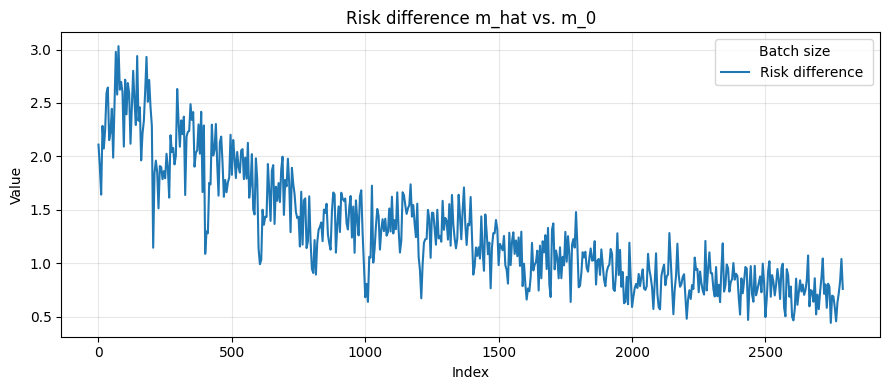

In [207]:
plt.figure(figsize=(9, 4))

seq = all_martingales[3]

plt.plot(np.arange(len(seq)) * smallest_batch, seq, label=f"Risk difference ")

plt.legend(title="Batch size")
plt.title("Risk difference m_hat vs. m_0")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()